# Código de investigación — Análisis estadístico

**Estudio:** efecto del tipo de modelo abierto de aprendizaje sobre autoeficacia, selección de subtópicos y desempeño.

**Grupos (factor principal):**

| Grupo | Descripción |
|---|---|
| `OLM` | Open Learner Model: el estudiante ve solo su propio progreso. Sin comparación social. |
| `OSLM` | Open Social Learner Model: además ve el progreso del grupo (comparación social). |
| `OSLM+VP` | OSLM + mensajes motivacionales / virtual peer. |

**Contrastes planificados** (en lugar de tratar `grupo` como factor nominal suelto):

- `comparacionOSLM` = 1 para OSLM y OSLM+VP, 0 para OLM → **efecto de exponer comparación social** (OSLM vs OLM).
- `comparacionOSLMVP` = 1 solo para OSLM+VP → **efecto adicional del mensaje motivacional** (OSLM+VP vs OSLM).

**Segundo factor: dirección de la comparación** (`direccion`): `arriba` (upward: el estudiante está por debajo del promedio del grupo), `abajo` (downward), `igual`, `no` (no se mostró comparación — solo OLM en `dfSecuencia`).

---
### Estructura del notebook
0. Configuración, carga de datos y diccionario de variables
1. Funciones auxiliares de análisis
2. Descriptivos por grupo
3. **Pregunta 2** — Autoeficacia: cambio según grupo y según dirección de comparación
4. **Pregunta 3.1** — Selección de subtópicos con comparación social (OSLM vs OSLM+VP)
5. **Pregunta 3.2** — Desempeño en la actividad (global y por dirección)
6. Gráficos exploratorios de desempeño
7. **Revisión inversa** — matriz de screening variable × factor (qué cambió y merece atención)
8. Síntesis de hallazgos y de correcciones aplicadas
9. **Qué es publicable** — qué podemos afirmar y sostener
10. Apéndice — construcción histórica de variables (referencia, no ejecutable con los datos actuales)

## 0. Configuración, carga de datos y diccionario de variables

### 0.1 Imports

In [88]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RNG = 123

# Requiere: pandas numpy scipy statsmodels matplotlib openpyxl

### 0.2 Carga de datos

> **Correcciones:**
> - El notebook original leía de `...\Desktop\MAGISTER\dfCongreso.xlsx`, un archivo desactualizado al que le faltaban columnas usadas más abajo (`performance_arriba/abajo`, `porce_topicos_arriba/abajo`) → las celdas de P3.1 y P3.2 lanzaban `KeyError`. Ahora se usan los archivos de **esta misma carpeta**.
> - Se usa **`dfSegmento.xlsx`** (no `dfSecuencia.xlsx`) como tabla de transiciones: `dfSecuencia` quedó del pipeline antiguo basado en `steps` y es **incoherente** con `dfUsuario` / `df_1_to_2` / `df_2_to_3` / `dfNivelEjercicio`, que ya usan métricas basadas en `attempts` (`total_attempts`, `first_attempts_correct`, `unique_steps`, `prop_first_attempts_correct`).

In [89]:
DATA_DIR = r"C:\Users\joaqu\OneDrive\Desktop\MAGISTER DEFINITIVO\tesis"

dfUsuario        = pd.read_excel(os.path.join(DATA_DIR, "dfUsuario.xlsx"))       # 1 fila = 1 usuario (acumulado)
dfSegmento       = pd.read_excel(os.path.join(DATA_DIR, "dfSegmento.xlsx"))      # 1 fila = transición entre polls dentro de un tópico
df_1_to_2        = pd.read_excel(os.path.join(DATA_DIR, "df_1_to_2.xlsx"))       # subconjunto: transición poll 1 -> 2
df_2_to_3        = pd.read_excel(os.path.join(DATA_DIR, "df_2_to_3.xlsx"))       # subconjunto: transición poll 2 -> 3
dfNivelEjercicio = pd.read_excel(os.path.join(DATA_DIR, "dfNivelEjercicio.xlsx"))# 1 fila = un bloque de ejercicio completado

for nombre, d in [("dfUsuario", dfUsuario), ("dfSegmento", dfSegmento),
                  ("df_1_to_2", df_1_to_2), ("df_2_to_3", df_2_to_3),
                  ("dfNivelEjercicio", dfNivelEjercicio)]:
    print(f"{nombre:18s} {d.shape[0]:5d} filas x {d.shape[1]:2d} cols | "
          f"{d['userid'].nunique():3d} usuarios | grupos: {d['grupo_intervencion'].value_counts().to_dict()}")

dfUsuario            181 filas x 47 cols | 181 usuarios | grupos: {'OSLM+VP': 71, 'OLM': 59, 'OSLM': 51}
dfSegmento           943 filas x 17 cols |  89 usuarios | grupos: {'OLM': 382, 'OSLM': 286, 'OSLM+VP': 275}
df_1_to_2            271 filas x 17 cols |  80 usuarios | grupos: {'OLM': 114, 'OSLM': 81, 'OSLM+VP': 76}
df_2_to_3            132 filas x 17 cols |  57 usuarios | grupos: {'OLM': 63, 'OSLM+VP': 39, 'OSLM': 30}
dfNivelEjercicio    5017 filas x 28 cols | 185 usuarios | grupos: {'OLM': 1899, 'OSLM+VP': 1647, 'OSLM': 1471}


### 0.3 Diccionario de variables (resumen)

**`dfUsuario`** (nivel usuario, acumulado):

| Variable | Significado |
|---|---|
| `primer_pollValue`, `autoeficacia_general` | autoeficacia (0–100): primera medición y promedio |
| `total_attempts`, `first_attempts_correct`, `unique_steps` | intentos totales, aciertos a la primera, pasos únicos |
| `prop_first_attempts_correct` = `performance` | proporción de pasos resueltos a la primera (desempeño) |
| `Tasa_exito`, `tasa_hints` | tasa de éxito y de uso de pistas |
| `progreso_inicial`, `progreso_inicial_grupo` | progreso propio / del grupo al inicio |
| `casos`, `casos_comparacion_arriba/abajo` | nº de bloques; nº con comparación upward / downward |
| `porce_topicos_arriba/abajo` | proporción de tópicos con comparación upward / downward |
| `performance_arriba/abajo` | desempeño en bloques con comparación upward / downward |
| `preferencia_casos_comparacion`, `preferencia_casos_uw` | preferencia por casos con comparación / upward (rango −1..1) |
| `*_comparacion_arriba/abajo` | métricas restringidas a bloques con esa dirección (muchos NaN estructurales) |

**`dfSegmento`** (nivel transición dentro de un tópico): `pollValue` → `pollValue_next`, `delta_pollValue`; `pollCount` es el **índice de medición dentro del tópico** (NO una ola global T1/T2/T3). `direccionComparacion` aquí = *qué se mostró* (OLM ⇒ `no`).

**`dfNivelEjercicio`** (nivel bloque de ejercicio): `direccionComparacion` aquí = *posición objetiva* respecto al grupo (definida también para OLM); propagada por usuario con ffill/bfill.

### 0.4 Preparación común

Recodifica `grupo_intervencion` como categórica ordenada, crea los contrastes planificados, normaliza las etiquetas de dirección y elimina infinitos (`tasa_hints` tenía `inf` por división por cero).

In [90]:
ORDEN_GRUPOS = ["OLM", "OSLM", "OSLM+VP"]
GRUPOS_COMP  = ["OSLM", "OSLM+VP"]          # grupos que SÍ reciben comparación social

_MAPA_DIR = {
    "upward": "arriba", "hacia arriba": "arriba", "arriba": "arriba",
    "downward": "abajo", "hacia abajo": "abajo", "abajo": "abajo",
    "equal": "igual", "igual": "igual",
    "no": "no", "none": "no", "nan": np.nan,
}

def preparar(df):
    df = df.copy()
    if "grupo_intervencion" in df.columns:
        df["grupo_intervencion"] = pd.Categorical(df["grupo_intervencion"],
                                                  categories=ORDEN_GRUPOS, ordered=True)
        df["comparacionOSLM"]   = (df["grupo_intervencion"] != "OLM").astype(int)
        df["comparacionOSLMVP"] = (df["grupo_intervencion"] == "OSLM+VP").astype(int)
    if "direccionComparacion" in df.columns:
        df["direccion"] = (df["direccionComparacion"].astype(str).str.strip().str.lower()
                           .map(_MAPA_DIR))
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

dfUsuario        = preparar(dfUsuario)
dfSegmento       = preparar(dfSegmento)
df_1_to_2        = preparar(df_1_to_2)
df_2_to_3        = preparar(df_2_to_3)
dfNivelEjercicio = preparar(dfNivelEjercicio)

print("dfUsuario grupos:", dfUsuario["grupo_intervencion"].value_counts().to_dict())
print("dfSegmento grupo x direccion:")
print(pd.crosstab(dfSegmento["grupo_intervencion"], dfSegmento["direccion"]))
print("\\nNota: en dfSegmento, direccion='no' coincide exactamente con OLM (confusión perfecta):")
print("  -> el factor 'direccion' en Pregunta 2 se analiza SOLO dentro de OSLM y OSLM+VP.")

dfUsuario grupos: {'OSLM+VP': 71, 'OLM': 59, 'OSLM': 51}
dfSegmento grupo x direccion:
direccion           abajo  arriba  igual   no
grupo_intervencion                           
OLM                     0       0      0  382
OSLM                   94     103     89    0
OSLM+VP                86     115     74    0
\nNota: en dfSegmento, direccion='no' coincide exactamente con OLM (confusión perfecta):
  -> el factor 'direccion' en Pregunta 2 se analiza SOLO dentro de OSLM y OSLM+VP.


## 1. Funciones auxiliares de análisis

Un solo lugar con: descriptivos robustos, chequeo de normalidad, **elección de test según supuestos**, **tamaños de efecto**, **corrección por comparaciones múltiples** (Holm / FDR-BH), post-hoc de Dunn y un envoltorio legible para modelos mixtos.

In [91]:
# ---- descriptivos -------------------------------------------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce").dropna()

def media_sd(s):
    s = to_num(s)
    if s.empty: return "—"
    sd = s.std(ddof=1)
    return f"{s.mean():.2f} ({0.0 if pd.isna(sd) else sd:.2f})"

def mediana_iqr(s):
    s = to_num(s)
    if s.empty: return "—"
    q1, q3 = s.quantile([.25, .75])
    return f"{s.median():.2f} [{q1:.2f}, {q3:.2f}]"

# ---- supuestos --------------------------------------------------------------
def normal_ok(s):
    s = to_num(s)
    n = len(s)
    if n < 3: return False
    s = s.sample(5000, random_state=RNG) if n > 5000 else s
    return stats.shapiro(s)[1] > .05

def tabla_normalidad(df, variables, grupos=None, grupo_col="grupo_intervencion"):
    filas = []
    grupos = grupos or list(df[grupo_col].dropna().unique())
    for v in variables:
        if v not in df.columns: continue
        for g in grupos:
            s = to_num(df.loc[df[grupo_col] == g, v]); n = len(s)
            if n >= 3:
                ss = s.sample(5000, random_state=RNG) if n > 5000 else s
                W, p = stats.shapiro(ss)
            else:
                W, p = np.nan, np.nan
            filas.append(dict(Variable=v, Grupo=str(g), n=n, Shapiro_W=W, Shapiro_p=p,
                              normal=("sí" if (pd.notna(p) and p > .05) else "no")))
    return pd.DataFrame(filas)

# ---- tamaños de efecto ------------------------------------------------------
def rank_biserial(U, n1, n2):
    return 1 - 2 * U / (n1 * n2)          # -1..1 ; signo: >0 => grupo 1 > grupo 2

def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) == 0 or len(b) == 0: return np.nan
    diff = a[:, None] - b[None, :]
    return (np.sign(diff).sum()) / (len(a) * len(b))

def epsilon2_kw(H, N):
    return (H - 1) / (N - 1) if N > 1 else np.nan   # 0..1

def eta2_anova(grupos):
    allx = np.concatenate([g.values for g in grupos]); gm = allx.mean()
    ssb = sum(len(g) * (g.mean() - gm) ** 2 for g in grupos)
    sst = ((allx - gm) ** 2).sum()
    return ssb / sst if sst else np.nan

def magnitud(ef, tipo):
    if pd.isna(ef): return "—"
    a = abs(ef)
    if tipo in ("rank-biserial", "Cliff delta", "r"):
        return "grande" if a >= .474 else "mediano" if a >= .33 else "pequeño" if a >= .1 else "trivial"
    if tipo in ("epsilon²", "eta²", "R²", "R²(≈)"):
        return "grande" if a >= .14 else "mediano" if a >= .06 else "pequeño" if a >= .01 else "trivial"
    if tipo == "Cohen d":
        return "grande" if a >= .8 else "mediano" if a >= .5 else "pequeño" if a >= .2 else "trivial"
    return "—"

# ---- corrección múltiple --------------------------------------------------
def ajustar_p(pvals, metodo="fdr_bh"):
    p = np.asarray(pvals, float); out = np.full(p.shape, np.nan)
    ok = ~np.isnan(p)
    if ok.sum():
        out[ok] = multipletests(p[ok], method=metodo)[1]
    return out

def estrella(p):
    if pd.isna(p): return ""
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""

# ---- contrastes -----------------------------------------------------------
def contraste_2(a, b, variable="", forzar=None):
    """OSLM vs OSLM+VP u otro par. forzar in {None,'param','noparam'}."""
    a, b = to_num(a), to_num(b)
    base = dict(variable=variable, n1=len(a), n2=len(b), test="—",
                stat=np.nan, p=np.nan, ef=np.nan, ef_tipo="—")
    if len(a) < 3 or len(b) < 3:
        return base
    param = (normal_ok(a) and normal_ok(b)) if forzar is None else (forzar == "param")
    if param:
        t, p = stats.ttest_ind(a, b, equal_var=False)
        d = (a.mean() - b.mean()) / np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
        base.update(test="Welch t", stat=t, p=p, ef=d, ef_tipo="Cohen d")
    else:
        U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        base.update(test="Mann–Whitney U", stat=U, p=p,
                    ef=rank_biserial(U, len(a), len(b)), ef_tipo="rank-biserial")
    return base

def contraste_k(grupos, variable="", forzar=None):
    arr = [to_num(g) for g in grupos]
    arr = [g for g in arr if len(g) >= 3]
    base = dict(variable=variable, test="—", stat=np.nan, p=np.nan, ef=np.nan, ef_tipo="—",
                n=sum(len(g) for g in arr), k=len(arr))
    if len(arr) < 2:
        return base
    N = sum(len(g) for g in arr)
    if forzar == "param":
        param = True
    elif forzar == "noparam":
        param = False
    else:
        param = all(normal_ok(g) for g in arr) and (stats.levene(*arr, center="median")[1] > .05)
    if param:
        F, p = stats.f_oneway(*arr)
        base.update(test="ANOVA", stat=F, p=p, ef=eta2_anova(arr), ef_tipo="eta²")
    else:
        H, p = stats.kruskal(*arr)
        base.update(test="Kruskal–Wallis", stat=H, p=p, ef=epsilon2_kw(H, N), ef_tipo="epsilon²")
    return base

def dunn_holm(df, val, grupo_col="grupo_intervencion"):
    d = df[[val, grupo_col]].dropna().copy()
    d[grupo_col] = d[grupo_col].astype(str)
    d["_r"] = d[val].rank()
    N = len(d)
    presentes = list(d[grupo_col].unique())
    gs = ([g for g in ORDEN_GRUPOS if g in presentes]
          + [g for g in presentes if g not in ORDEN_GRUPOS])
    Rbar = d.groupby(grupo_col)["_r"].mean()
    n = d.groupby(grupo_col)["_r"].size()
    tie = d["_r"].value_counts()
    sigma2 = (N * (N + 1) / 12) - (tie ** 3 - tie).sum() / (12 * (N - 1))
    filas = []
    for g1, g2 in itertools.combinations(gs, 2):
        z = (Rbar[g1] - Rbar[g2]) / np.sqrt(sigma2 * (1 / n[g1] + 1 / n[g2]))
        filas.append(dict(g1=g1, g2=g2, z=z, p=2 * stats.norm.sf(abs(z))))
    r = pd.DataFrame(filas)
    r["p_holm"] = ajustar_p(r["p"], "holm")
    return r

# ---- modelos con datos agrupados por usuario --------------------------------
# Hay varias observaciones por usuario (transiciones/bloques). En vez de un modelo
# mixto (que aquí converge a Var_usuario≈0 y se vuelve singular con predictores
# entre-sujetos), se usa OLS con errores estándar robustos por conglomerado
# (cluster = userid). El ICC no condicionado se reporta aparte para justificarlo.

def icc_no_condicionado(data, y, grupo="userid"):
    d = data[[y, grupo]].dropna().copy()
    d[grupo] = d[grupo].astype(str)
    try:
        r = smf.mixedlm(f"{y} ~ 1", d, groups=d[grupo]).fit(reml=True, method="lbfgs")
        gv = float(np.ravel(r.cov_re)[0]); rv = float(r.scale)
        return gv / (gv + rv) if (gv + rv) else np.nan
    except Exception:
        return np.nan

def modelo_cluster(formula, data, cluster="userid", titulo="", estandarizar=None):
    d = data.copy()
    for c in (estandarizar or []):
        if c in d.columns:
            s = pd.to_numeric(d[c], errors="coerce")
            d[c] = (s - s.mean()) / s.std(ddof=0)
    res = smf.ols(formula, d).fit(cov_type="cluster",
                                  cov_kwds={"groups": d[cluster].astype(str)})
    tab = pd.DataFrame(dict(coef=res.params, SE=res.bse, z=res.tvalues, p=res.pvalues))
    tab["sig"] = [estrella(p) for p in tab["p"]]
    y = formula.split("~")[0].strip()
    print(f"{titulo}\n  N obs = {int(res.nobs)} | usuarios = {d[cluster].nunique()} | "
          f"R² = {res.rsquared:.3f} | ICC(no cond.) {y} = {icc_no_condicionado(d, y, cluster):.3f}")
    return tab.round(4), res

def omnibus_terminos(res):
    """Wald por término del modelo (usa la matriz de covarianzas del ajuste: robusta si se pidió)."""
    w = res.wald_test_terms(scalar=True)
    t = w.summary_frame()
    t.columns = [str(c) for c in t.columns]
    return t

def mixedlm_tabla(formula, data, grupo="userid", titulo=""):
    """Modelo mixto (intercepto aleatorio por 'grupo'). Úsalo solo cuando el ICC es alto."""
    d = data.copy(); d[grupo] = d[grupo].astype(str)
    res = smf.mixedlm(formula, d, groups=d[grupo]).fit(method="lbfgs")
    fe, se = res.fe_params, res.bse_fe
    z = fe / se
    tab = pd.DataFrame(dict(coef=fe, SE=se, z=z, p=2 * stats.norm.sf(np.abs(z))))
    tab["sig"] = [estrella(p) for p in tab["p"]]
    gv = float(np.ravel(res.cov_re)[0]); rv = float(res.scale)
    print(f"{titulo}\n  N obs = {int(res.nobs)} | usuarios = {res.model.n_groups} | "
          f"ICC = {gv / (gv + rv):.3f}")
    return tab.round(4), res

print("Funciones cargadas.")

Funciones cargadas.


## 2. Descriptivos por grupo

### 2.1 Autoeficacia a lo largo de las mediciones (`dfSegmento`)

> **Corrección al análisis original:** la celda antigua interpretaba `pollCount ∈ {1,2,3}` como olas globales T1/T2/T3 y hacía un `pivot_table` por `userid` promediando entre tópicos. `pollCount` es en realidad el número de medición **dentro de cada tópico** (llega hasta 14), así que ese pivote mezclaba tópicos distintos en una misma celda. Aquí se describe `pollValue` por `grupo × pollCount` (1–3, que son las mediciones con N razonable) y el cambio **dentro del tópico** (`delta_pollValue`) por grupo y dirección.

In [92]:
se = dfSegmento.copy()

# (a) Nivel de autoeficacia por grupo y nº de medición dentro del tópico
tab_nivel = (se[se["pollCount"].between(1, 3)]
             .groupby(["grupo_intervencion", "pollCount"], observed=True)["pollValue"]
             .agg(N="count", media="mean", sd="std", mediana="median").round(2))
print("Autoeficacia (pollValue 0–100) por grupo y medición dentro del tópico:")
print(tab_nivel)

# (b) Cambio dentro del tópico (una transición = una fila con pollValue_next observado)
cambio = se.dropna(subset=["delta_pollValue"]).copy()
print("\nΔ autoeficacia por transición (pollValue_next - pollValue), por grupo:")
print(cambio.groupby("grupo_intervencion")["delta_pollValue"]
      .agg(N="count", media="mean", sd="std", mediana="median",
           pct_sube=lambda x: (x > 0).mean() * 100,
           pct_baja=lambda x: (x < 0).mean() * 100).round(2))

print("\nΔ autoeficacia por dirección de comparación (solo OSLM y OSLM+VP):")
print(cambio[cambio["grupo_intervencion"].isin(GRUPOS_COMP)]
      .groupby(["grupo_intervencion", "direccion"], observed=True)["delta_pollValue"]
      .agg(N="count", media="mean", mediana="median").round(2))

Autoeficacia (pollValue 0–100) por grupo y medición dentro del tópico:
                                N   media      sd  mediana
grupo_intervencion pollCount                              
OLM                1          102 53.6300 29.9100  50.0000
                   2          102 71.7600 26.7100  77.0000
                   3           60 67.8000 29.6200  61.0000
OSLM               1           94 64.3600 33.8400  65.5000
                   2           93 75.0900 29.0300  86.0000
                   3           47 72.6800 32.3600  96.0000
OSLM+VP            1           90 52.1400 26.9400  50.5000
                   2           99 71.2400 25.3900  75.0000
                   3           49 78.5100 27.0800  87.0000

Δ autoeficacia por transición (pollValue_next - pollValue), por grupo:
                      N   media      sd  mediana  pct_sube  pct_baja
grupo_intervencion                                                  
OLM                 203 13.3000 22.2300   9.0000   64.0400   13.3000
O

### 2.2 Descriptivos de `dfUsuario` por grupo

> **Correcciones:** (1) nombres de columna actualizados al dataset vigente (`Steps`→`unique_steps`, `Att1c`→`first_attempts_correct`); (2) se elimina la heurística frágil "si la mediana > 1 asumo escala 0–100" del antiguo `pct_times_total` — `porce_topicos_*` ya vienen como proporción 0–1, así que los **subtópicos esperados** son simplemente `porce_topicos_* * casos`; (3) se reporta **mediana [IQR]** junto a media (SD) porque varias de estas variables son muy asimétricas.

In [93]:
# Subtópicos esperados con comparación upward / downward = proporción de tópicos * nº de casos
# (reemplaza al antiguo pct_times_total, que fallaba si la columna no existía y usaba una
#  heurística de escala poco fiable). porce_topicos_* ya está en proporción 0–1.
_casos = pd.to_numeric(dfUsuario["casos"], errors="coerce")
dfUsuario["Subtopicos_UW_prom"] = pd.to_numeric(dfUsuario["porce_topicos_arriba"], errors="coerce") * _casos
dfUsuario["Subtopicos_DW_prom"] = pd.to_numeric(dfUsuario["porce_topicos_abajo"],  errors="coerce") * _casos

FILAS_DESC = [
    ("Autoeficacia inicial (primer_pollValue)", "primer_pollValue"),
    ("Autoeficacia promedio (autoeficacia_general)", "autoeficacia_general"),
    ("Nº de casos/bloques (casos)", "casos"),
    ("Intentos totales (total_attempts)", "total_attempts"),
    ("Aciertos a la primera (first_attempts_correct)", "first_attempts_correct"),
    ("Pasos únicos (unique_steps)", "unique_steps"),
    ("Desempeño = prop. aciertos 1er intento (performance)", "performance"),
    ("Tasa de éxito (Tasa_exito)", "Tasa_exito"),
    ("Nº de pistas (numero_hints)", "numero_hints"),
    ("Sesiones distintas (numero_sesiones_diferentes)", "numero_sesiones_diferentes"),
    ("Tiempo total s (tiempo_total_segundos)", "tiempo_total_segundos"),
    ("Rating de selección (selectionRating_result)", "selectionRating_result"),
    ("Progreso inicial propio (progreso_inicial)", "progreso_inicial"),
    ("% tópicos con comparación upward (porce_topicos_arriba)", "porce_topicos_arriba"),
    ("% tópicos con comparación downward (porce_topicos_abajo)", "porce_topicos_abajo"),
    ("Subtópicos esperados upward (Subtopicos_UW_prom)", "Subtopicos_UW_prom"),
    ("Subtópicos esperados downward (Subtopicos_DW_prom)", "Subtopicos_DW_prom"),
    ("Casos comparación upward (casos_comparacion_arriba)", "casos_comparacion_arriba"),
    ("Casos comparación downward (casos_comparacion_abajo)", "casos_comparacion_abajo"),
    ("Desempeño en casos upward (performance_arriba)", "performance_arriba"),
    ("Desempeño en casos downward (performance_abajo)", "performance_abajo"),
    ("Preferencia por casos con comparación (preferencia_casos_comparacion)", "preferencia_casos_comparacion"),
    ("Preferencia por casos upward (preferencia_casos_uw)", "preferencia_casos_uw"),
]

def tabla_descriptiva(df, filas, grupos=ORDEN_GRUPOS, resumen=media_sd):
    out = pd.DataFrame(index=[f[0] for f in filas], columns=grupos, dtype=object)
    for etiqueta, col in filas:
        for g in grupos:
            out.loc[etiqueta, g] = resumen(df.loc[df["grupo_intervencion"] == g, col]) if col in df.columns else "—"
    return out

print("=== Media (SD) por grupo ===")
print(tabla_descriptiva(dfUsuario, FILAS_DESC, resumen=media_sd).to_string())
print("\n=== Mediana [IQR] por grupo ===")
print(tabla_descriptiva(dfUsuario, FILAS_DESC, resumen=mediana_iqr).to_string())

N_grupo = dfUsuario.groupby("grupo_intervencion")["userid"].nunique()
print("\nN por grupo:", N_grupo.to_dict())

=== Media (SD) por grupo ===


                                                                                     OLM               OSLM            OSLM+VP
Autoeficacia inicial (primer_pollValue)                                    54.68 (32.73)      59.48 (31.63)      60.01 (31.41)
Autoeficacia promedio (autoeficacia_general)                               60.33 (30.42)      65.59 (29.79)      66.53 (29.13)
Nº de casos/bloques (casos)                                                24.69 (31.34)      25.61 (26.07)      23.20 (27.18)
Intentos totales (total_attempts)                                          84.58 (95.78)      87.22 (80.87)      78.15 (87.64)
Aciertos a la primera (first_attempts_correct)                             44.85 (65.29)      44.27 (49.73)      41.75 (51.84)
Pasos únicos (unique_steps)                                                58.17 (74.78)      60.45 (61.86)      56.21 (66.37)
Desempeño = prop. aciertos 1er intento (performance)                         0.71 (0.20)        0.70 (0.16)    

## 3. Pregunta 2 — Autoeficacia: ¿cambia según el grupo y según la dirección de comparación?

Variable dependiente: `pollValue_next` (autoeficacia en la siguiente medición dentro del mismo tópico). Modelo autorregresivo (`pollValue` previa como predictor).

> **Corrección al modelo original:** el notebook usaba `mixedlm` con intercepto aleatorio por `userid`, pero con estos datos la varianza entre usuarios colapsa a ≈0 y el modelo se vuelve **singular** cuando se añaden predictores entre-sujetos (grupo, dirección). Como hay varias transiciones por usuario, se usa **OLS con errores estándar robustos por conglomerado** (`cluster = userid`), que corrige la no-independencia sin depender de esa varianza. El ICC no condicionado se reporta para justificarlo.

Predictores de control (estandarizados): `pollValue`, `total_attempts`, `first_attempts_correct`, `last_progressMe`. Se quita `selectionRating_result` del modelo principal (efecto techo: mediana = 5, ~80% en el valor 5, y su NA eliminaba ~84 filas).

### 3.1 Contrastes planificados de grupo — todas las transiciones (`dfSegmento`)

In [94]:
COVARIABLES = ["pollValue", "total_attempts", "first_attempts_correct", "last_progressMe"]

def preparar_se(df, extra):
    d = df.copy()
    for c in ["pollValue_next"] + COVARIABLES:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    cols = ["userid", "pollValue_next"] + COVARIABLES + extra
    cols = [c for c in dict.fromkeys(cols) if c in d.columns]
    return d[cols].dropna().reset_index(drop=True)

ESTANDARIZAR = ["pollValue", "total_attempts", "first_attempts_correct", "last_progressMe"]
FORMULA_G = ("pollValue_next ~ pollValue + total_attempts + first_attempts_correct + "
             "last_progressMe + comparacionOSLM + comparacionOSLMVP")

d_gen = preparar_se(dfSegmento, ["comparacionOSLM", "comparacionOSLMVP"])
tab_gen, res_gen = modelo_cluster(FORMULA_G, d_gen, estandarizar=ESTANDARIZAR,
                                  titulo="P2 — todas las transiciones (dfSegmento)")
print(tab_gen)
print("\nLectura de contrastes (coef en puntos de autoeficacia 0–100):")
print("  comparacionOSLM   = OSLM  - OLM   (efecto de exponer comparación social)")
print("  comparacionOSLMVP = OSLM+VP - OSLM (efecto adicional del mensaje motivacional)")

# Sensibilidad: con selectionRating_result
d_sens = preparar_se(dfSegmento.assign(selectionRating_result=pd.to_numeric(
    dfSegmento["selectionRating_result"], errors="coerce")),
    ["comparacionOSLM", "comparacionOSLMVP", "selectionRating_result"])
tab_sens, _ = modelo_cluster(FORMULA_G + " + selectionRating_result", d_sens,
                             estandarizar=ESTANDARIZAR + ["selectionRating_result"],
                             titulo="\nP2 — sensibilidad (+ selectionRating_result)")
print(tab_sens)

P2 — todas las transiciones (dfSegmento)
  N obs = 493 | usuarios = 80 | R² = 0.500 | ICC(no cond.) pollValue_next = 0.528
                          coef     SE       z      p  sig
Intercept              75.5016 1.6426 45.9650 0.0000  ***
pollValue              16.9368 1.8900  8.9614 0.0000  ***
total_attempts         -1.1945 0.9596 -1.2448 0.2132     
first_attempts_correct  3.5397 1.6363  2.1632 0.0305    *
last_progressMe         2.1786 0.7437  2.9296 0.0034   **
comparacionOSLM        -0.7551 3.8479 -0.1962 0.8444     
comparacionOSLMVP       4.2534 3.9854  1.0672 0.2859     

Lectura de contrastes (coef en puntos de autoeficacia 0–100):
  comparacionOSLM   = OSLM  - OLM   (efecto de exponer comparación social)
  comparacionOSLMVP = OSLM+VP - OSLM (efecto adicional del mensaje motivacional)

P2 — sensibilidad (+ selectionRating_result)
  N obs = 474 | usuarios = 79 | R² = 0.536 | ICC(no cond.) pollValue_next = 0.527
                          coef     SE       z      p  sig
Intercep

### 3.2 Mismo modelo por transición: D1→D2 y D2→D3

In [95]:
for nombre, dfx in [("D1→D2 (df_1_to_2)", df_1_to_2), ("D2→D3 (df_2_to_3)", df_2_to_3)]:
    d = preparar_se(dfx, ["comparacionOSLM", "comparacionOSLMVP"])
    print("=" * 70)
    tab, _ = modelo_cluster(FORMULA_G, d, estandarizar=ESTANDARIZAR, titulo=f"P2 — {nombre}")
    print(tab)

P2 — D1→D2 (df_1_to_2)
  N obs = 242 | usuarios = 77 | R² = 0.484 | ICC(no cond.) pollValue_next = 0.634
                          coef     SE       z      p  sig
Intercept              74.4698 2.7306 27.2725 0.0000  ***
pollValue              15.9404 2.0835  7.6508 0.0000  ***
total_attempts         -2.2444 1.3139 -1.7082 0.0876     
first_attempts_correct  3.8540 2.0592  1.8716 0.0613     
last_progressMe         3.3479 1.0976  3.0501 0.0023   **
comparacionOSLM         0.4990 4.6636  0.1070 0.9148     
comparacionOSLMVP       2.9320 4.6448  0.6312 0.5279     
P2 — D2→D3 (df_2_to_3)
  N obs = 116 | usuarios = 55 | R² = 0.571 | ICC(no cond.) pollValue_next = 0.546
                          coef     SE       z      p  sig
Intercept              74.6607 2.2674 32.9285 0.0000  ***
pollValue              19.7846 1.8897 10.4700 0.0000  ***
total_attempts          0.0511 2.0253  0.0252 0.9799     
first_attempts_correct  3.0358 2.4767  1.2258 0.2203     
last_progressMe         1.4543 1.564

### 3.3 Efecto de la **dirección** de comparación (solo OSLM y OSLM+VP)

En `dfSegmento`, `direccion='no'` coincide exactamente con OLM (a OLM no se le muestra comparación), así que grupo y dirección están perfectamente confundidos si se incluye OLM. El efecto de la dirección se estima **dentro de los grupos con comparación social**, junto con su interacción con el mensaje motivacional (`comparacionOSLMVP`). Referencia de `direccion` = `igual`.

In [96]:
d_dir = dfSegmento[dfSegmento["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
d_dir = preparar_se(d_dir.assign(direccion=d_dir["direccion"]),
                    ["comparacionOSLMVP", "direccion"])
d_dir = d_dir[d_dir["direccion"].isin(["arriba", "abajo", "igual"])].copy()
d_dir["direccion"] = pd.Categorical(d_dir["direccion"], ["igual", "arriba", "abajo"])

FORMULA_DIR = ("pollValue_next ~ pollValue + total_attempts + first_attempts_correct + "
               "last_progressMe + comparacionOSLMVP * C(direccion)")
tab_dir, res_dir = modelo_cluster(FORMULA_DIR, d_dir, estandarizar=ESTANDARIZAR,
                                  titulo="P2 — dirección x mensaje motivacional (OSLM ∪ OSLM+VP)")
print(tab_dir)
print("\nTests omnibus por término (Wald robusto):")
print(omnibus_terminos(res_dir).round(4))

P2 — dirección x mensaje motivacional (OSLM ∪ OSLM+VP)
  N obs = 290 | usuarios = 51 | R² = 0.539 | ICC(no cond.) pollValue_next = 0.523
                                            coef     SE       z      p  sig
Intercept                                77.9854 4.1520 18.7824 0.0000  ***
C(direccion)[T.arriba]                   -1.9236 5.9890 -0.3212 0.7481     
C(direccion)[T.abajo]                    -3.6309 4.1940 -0.8657 0.3866     
pollValue                                17.0227 2.4955  6.8213 0.0000  ***
total_attempts                            0.9809 1.1028  0.8895 0.3737     
first_attempts_correct                    4.5572 1.3459  3.3859 0.0007  ***
last_progressMe                           2.7597 2.7368  1.0084 0.3133     
comparacionOSLMVP                        -2.6418 6.0534 -0.4364 0.6625     
comparacionOSLMVP:C(direccion)[T.arriba]  6.7359 4.9853  1.3512 0.1766     
comparacionOSLMVP:C(direccion)[T.abajo]  12.0442 6.0615  1.9870 0.0469    *

Tests omnibus por término 

### 3.4 Cambio de autoeficacia — análisis a nivel usuario (sin pseudorreplicación)

> **Corrección importante:** hacer Kruskal–Wallis sobre las ~490 transiciones `delta_pollValue` **infla la significancia** porque cada usuario aporta varias transiciones no independientes (pseudorreplicación). Aquí se agrega a **una observación por usuario** (media de `delta_pollValue`) antes de comparar grupos, y se añade un **ANCOVA ajustando por la autoeficacia basal** (hay regresión a la media: quien parte bajo sube más) y un **modelo de crecimiento** `pollValue ~ tiempo × grupo`.

In [97]:
tr = dfSegmento.dropna(subset=["delta_pollValue"]).copy()

# (0) N efectivo
print("Transiciones y usuarios con Δ observado, por grupo:")
print(tr.groupby("grupo_intervencion", observed=True)
      .agg(transiciones=("delta_pollValue", "size"), usuarios=("userid", "nunique")))

# (1) UNA observación por usuario = media de delta_pollValue
pu = (tr.groupby(["userid", "grupo_intervencion"], observed=True)["delta_pollValue"]
        .mean().reset_index())
print("\nΔ autoeficacia por usuario (media), por grupo:")
print(pu.groupby("grupo_intervencion", observed=True)["delta_pollValue"]
      .agg(n="count", media="mean", mediana="median", sd="std",
           pct_sube=lambda x: (x > 0).mean() * 100).round(2))

r_g = contraste_k([pu.loc[pu.grupo_intervencion == g, "delta_pollValue"] for g in ORDEN_GRUPOS],
                  variable="Δ por usuario ~ grupo")
print(f"\nKruskal–Wallis (por usuario): H={r_g['stat']:.2f}, p={r_g['p']:.4f}, "
      f"{r_g['ef_tipo']}={r_g['ef']:.3f} ({magnitud(r_g['ef'], r_g['ef_tipo'])})")
print(dunn_holm(pu, "delta_pollValue").round(4))

# (2) ANCOVA ajustando por autoeficacia basal (primer pollValue del usuario)
base = (dfSegmento.sort_values(["userid", "topiclabel", "pollCount"])
        .groupby("userid", observed=True).agg(base=("pollValue", "first")).reset_index())
anc = pu.merge(base, on="userid").dropna()
anc["grupo"] = pd.Categorical(anc["grupo_intervencion"], ORDEN_GRUPOS)
m_anc = smf.ols('delta_pollValue ~ base + C(grupo, Treatment("OLM"))', anc).fit()
print(f"\nANCOVA (Δ ~ basal + grupo), N={int(m_anc.nobs)}  |  ref = OLM")
print(pd.DataFrame({"coef": m_anc.params, "SE": m_anc.bse, "t": m_anc.tvalues,
                    "p": m_anc.pvalues}).round(4))

# (3) Modelo de crecimiento: pollValue ~ tiempo (pollCount 1..3) x grupo, RE por usuario
lg = dfSegmento[["userid", "topiclabel", "pollCount", "pollValue", "grupo_intervencion"]].dropna(subset=["pollValue"]).copy()
lg = lg[lg["pollCount"].between(1, 3)]
lg["t"] = lg["pollCount"] - 1
lg["grupo"] = pd.Categorical(lg["grupo_intervencion"], ORDEN_GRUPOS)
tab_g, _ = mixedlm_tabla("pollValue ~ t * C(grupo, Treatment('OLM'))", lg,
                         titulo="Modelo de crecimiento — pollValue ~ tiempo x grupo (RE usuario)")
print(tab_g)
_res_lg = smf.ols("pollValue ~ t * C(grupo, Treatment('OLM'))", lg).fit(
    cov_type="cluster", cov_kwds={"groups": lg["userid"].astype(str)})
print("\nTests omnibus por término (Wald robusto por usuario):")
print(omnibus_terminos(_res_lg).round(4))

# (4) Dirección de comparación y cambio (por usuario, dentro de OSLM u OSLM+VP)
pud = (tr[tr["grupo_intervencion"].isin(GRUPOS_COMP) & tr["direccion"].isin(["arriba", "abajo", "igual"])]
       .groupby(["userid", "direccion"], observed=True)["delta_pollValue"].mean().reset_index())
r_d = contraste_k([pud.loc[pud.direccion == d, "delta_pollValue"] for d in ["igual", "arriba", "abajo"]],
                  variable="Δ ~ dirección")
print(f"\nΔ autoeficacia por dirección (media por usuario x dirección): "
      f"KW H={r_d['stat']:.2f}, p={r_d['p']:.4f}")

Transiciones y usuarios con Δ observado, por grupo:
                    transiciones  usuarios
grupo_intervencion                        
OLM                          203        29
OSLM                         149        27
OSLM+VP                      141        24

Δ autoeficacia por usuario (media), por grupo:
                     n   media  mediana      sd  pct_sube
grupo_intervencion                                       
OLM                 29 13.6900  14.0000 11.4500   79.3100
OSLM                27  7.3300   8.0000  9.2900   74.0700
OSLM+VP             24 13.1600  11.4700 13.1900   79.1700

Kruskal–Wallis (por usuario): H=3.36, p=0.1866, epsilon²=0.030 (pequeño)
     g1       g2       z      p  p_holm
0   OLM     OSLM  1.7331 0.0831  0.2492
1   OLM  OSLM+VP  0.2842 0.7763  0.7763
2  OSLM  OSLM+VP -1.3726 0.1699  0.3398

ANCOVA (Δ ~ basal + grupo), N=80  |  ref = OLM
                                         coef     SE       t      p
Intercept                             21.3268

## 4. Pregunta 3.1 — Selección de subtópicos con comparación social (OSLM vs OSLM+VP)

Variables: proporción de tópicos upward/downward, preferencia por casos con comparación y por casos upward, y progreso inicial.

> **Correcciones:** (1) **consistencia** — se decide el test por los supuestos y se reporta la normalidad *antes*; dadas las distribuciones (proporciones acotadas, muy asimétricas) el análisis principal es no paramétrico; (2) se añaden **mediana [IQR]**, **tamaño de efecto** (rank-biserial / epsilon²) y **corrección múltiple Holm** sobre el conjunto de contrastes de la pregunta; (3) para `progreso_inicial` (3 grupos) se usa Kruskal–Wallis + post-hoc Dunn.

> ⚠️ `progreso_inicial_grupo` arrastra el centinela `-1` ("sin comparación") promediado dentro de su construcción (rango observado −1…0.7). El contraste se reporta pero debería recalcularse excluyendo `last_progressGroup == -1` en el preprocesamiento.

In [98]:
VARS_P31 = {
    "PropTup (porce_topicos_arriba)":            "porce_topicos_arriba",
    "PropTdown (porce_topicos_abajo)":           "porce_topicos_abajo",
    "PrefTcomp (preferencia_casos_comparacion)": "preferencia_casos_comparacion",
    "PrefTup (preferencia_casos_uw)":            "preferencia_casos_uw",
}
d31 = dfUsuario[dfUsuario["grupo_intervencion"].isin(GRUPOS_COMP)]

print("Normalidad por grupo (diagnóstico):")
print(tabla_normalidad(d31, list(VARS_P31.values()) + ["progreso_inicial_grupo"], grupos=GRUPOS_COMP).round(4).to_string())

print("\nDescriptivos OSLM vs OSLM+VP  —  mediana [IQR]:")
for et, col in VARS_P31.items():
    print(f"  {et:45s} OSLM={mediana_iqr(d31.loc[d31.grupo_intervencion=='OSLM', col]):>18s}   "
          f"OSLM+VP={mediana_iqr(d31.loc[d31.grupo_intervencion=='OSLM+VP', col]):>18s}")

filas = []
for et, col in VARS_P31.items():
    filas.append(contraste_2(d31.loc[d31.grupo_intervencion == "OSLM", col],
                             d31.loc[d31.grupo_intervencion == "OSLM+VP", col], variable=et))
# progreso_inicial: 3 grupos
r_prog3 = contraste_k([dfUsuario.loc[dfUsuario.grupo_intervencion == g, "progreso_inicial"] for g in ORDEN_GRUPOS],
                      variable="progreso_inicial ~ grupo (3)")
# progreso_inicial_grupo: OSLM vs OSLM+VP
r_progg = contraste_2(d31.loc[d31.grupo_intervencion == "OSLM", "progreso_inicial_grupo"],
                      d31.loc[d31.grupo_intervencion == "OSLM+VP", "progreso_inicial_grupo"],
                      variable="progreso_inicial_grupo (OSLM vs OSLM+VP)")
filas += [r_prog3, r_progg]

res31 = pd.DataFrame(filas)
res31["p_holm"] = ajustar_p(res31["p"], "holm")
res31["magnitud"] = [magnitud(e, t) for e, t in zip(res31["ef"], res31["ef_tipo"])]
res31["sig"] = [estrella(p) for p in res31["p_holm"]]
print("\n=== Contrastes P3.1 (p_holm = corregido por comparaciones múltiples) ===")
print(res31[["variable", "test", "stat", "p", "p_holm", "ef", "ef_tipo", "magnitud", "sig"]].round(4).to_string(index=False))

print("\nPost-hoc Dunn–Holm para progreso_inicial (3 grupos):")
print(dunn_holm(dfUsuario, "progreso_inicial").round(4))

Normalidad por grupo (diagnóstico):
                        Variable    Grupo   n  Shapiro_W  Shapiro_p normal
0           porce_topicos_arriba     OSLM  51     0.6737     0.0000     no
1           porce_topicos_arriba  OSLM+VP  71     0.6663     0.0000     no
2            porce_topicos_abajo     OSLM  51     0.8444     0.0000     no
3            porce_topicos_abajo  OSLM+VP  71     0.7334     0.0000     no
4  preferencia_casos_comparacion     OSLM  51     0.8033     0.0000     no
5  preferencia_casos_comparacion  OSLM+VP  71     0.7533     0.0000     no
6           preferencia_casos_uw     OSLM  36     0.7896     0.0000     no
7           preferencia_casos_uw  OSLM+VP  38     0.9008     0.0027     no
8         progreso_inicial_grupo     OSLM  38     0.5349     0.0000     no
9         progreso_inicial_grupo  OSLM+VP  43     0.5236     0.0000     no

Descriptivos OSLM vs OSLM+VP  —  mediana [IQR]:
  PropTup (porce_topicos_arriba)                OSLM= 0.00 [0.00, 0.24]   OSLM+VP= 0.00 [0

## 5. Pregunta 3.2 — Desempeño en la actividad (global y por dirección)

`performance` = `prop_first_attempts_correct` (proporción de pasos resueltos al primer intento).

> **Corrección importante — ceros estructurales:** `performance_arriba` / `performance_abajo` en `dfUsuario` se rellenaron con **0** para usuarios que nunca tuvieron esa dirección de comparación. Eso mezcla "desempeño 0" con "no aplica" y sesga la comparación. Aquí se reportan **dos versiones**: (a) tal cual está el dataset (con los 0) y (b) **condicional** — solo usuarios con ≥1 caso en esa dirección. La versión (b) es la interpretable.

In [99]:
d32 = dfUsuario.copy()

# ---- (1) PerfAtt global, 3 grupos ----
r_glob = contraste_k([d32.loc[d32.grupo_intervencion == g, "performance"] for g in ORDEN_GRUPOS],
                     variable="performance (global) ~ grupo (3)")
print(f"{r_glob['test']} performance global ~ grupo: stat={r_glob['stat']:.2f}, p={r_glob['p']:.4f}, "
      f"{r_glob['ef_tipo']}={r_glob['ef']:.3f} ({magnitud(r_glob['ef'], r_glob['ef_tipo'])})")
print(dunn_holm(d32, "performance").round(4))

print("\nDescriptivos performance global (mediana [IQR]):")
for g in ORDEN_GRUPOS:
    print(f"  {g:8s} {mediana_iqr(d32.loc[d32.grupo_intervencion == g, 'performance'])}")

# ---- (2) performance por dirección, OSLM vs OSLM+VP ----
def perf_dir(condicional):
    filas = []
    for col, dir_casos in [("performance_arriba", "casos_comparacion_arriba"),
                           ("performance_abajo",  "casos_comparacion_abajo")]:
        sub = d32[d32["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
        if condicional:
            sub = sub[pd.to_numeric(sub[dir_casos], errors="coerce") > 0]
        r = contraste_2(sub.loc[sub.grupo_intervencion == "OSLM", col],
                        sub.loc[sub.grupo_intervencion == "OSLM+VP", col],
                        variable=f"{col} (OSLM vs OSLM+VP)")
        r["OSLM_mediana_IQR"]    = mediana_iqr(sub.loc[sub.grupo_intervencion == "OSLM", col])
        r["OSLM+VP_mediana_IQR"] = mediana_iqr(sub.loc[sub.grupo_intervencion == "OSLM+VP", col])
        filas.append(r)
    t = pd.DataFrame(filas)
    t["p_holm"] = ajustar_p(t["p"], "holm")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

print("\n=== (a) performance por dirección — dataset tal cual (con 0 estructurales) ===")
print(perf_dir(False)[["variable", "n1", "n2", "test", "stat", "p", "p_holm", "ef", "magnitud",
                       "OSLM_mediana_IQR", "OSLM+VP_mediana_IQR"]].round(4).to_string(index=False))
print("\n=== (b) performance por dirección — CONDICIONAL (solo usuarios con casos en esa dirección) ===")
print(perf_dir(True)[["variable", "n1", "n2", "test", "stat", "p", "p_holm", "ef", "magnitud",
                      "OSLM_mediana_IQR", "OSLM+VP_mediana_IQR"]].round(4).to_string(index=False))

Kruskal–Wallis performance global ~ grupo: stat=1.62, p=0.4440, epsilon²=0.003 (trivial)
     g1       g2      z      p  p_holm
0   OLM     OSLM 0.5534 0.5800  1.0000
1   OLM  OSLM+VP 1.2704 0.2039  0.6118
2  OSLM  OSLM+VP 0.6428 0.5204  1.0000

Descriptivos performance global (mediana [IQR]):
  OLM      0.74 [0.61, 0.83]
  OSLM     0.69 [0.61, 0.83]
  OSLM+VP  0.71 [0.55, 0.82]

=== (a) performance por dirección — dataset tal cual (con 0 estructurales) ===
                            variable  n1  n2           test       stat      p  p_holm      ef magnitud  OSLM_mediana_IQR OSLM+VP_mediana_IQR
performance_arriba (OSLM vs OSLM+VP)  51  71 Mann–Whitney U 1,825.5000 0.9287  0.9287 -0.0083  trivial 0.00 [0.00, 0.57]   0.00 [0.00, 0.61]
 performance_abajo (OSLM vs OSLM+VP)  51  71 Mann–Whitney U 2,198.0000 0.0335  0.0669 -0.2140  pequeño 0.60 [0.00, 0.76]   0.00 [0.00, 0.68]

=== (b) performance por dirección — CONDICIONAL (solo usuarios con casos en esa dirección) ===
                   

## 6. Gráficos exploratorios de desempeño

Se conserva el bloque original (distribuciones de intentos y desempeño). `performance` = `prop_first_attempts_correct` ya viene acotado en [0, 1].

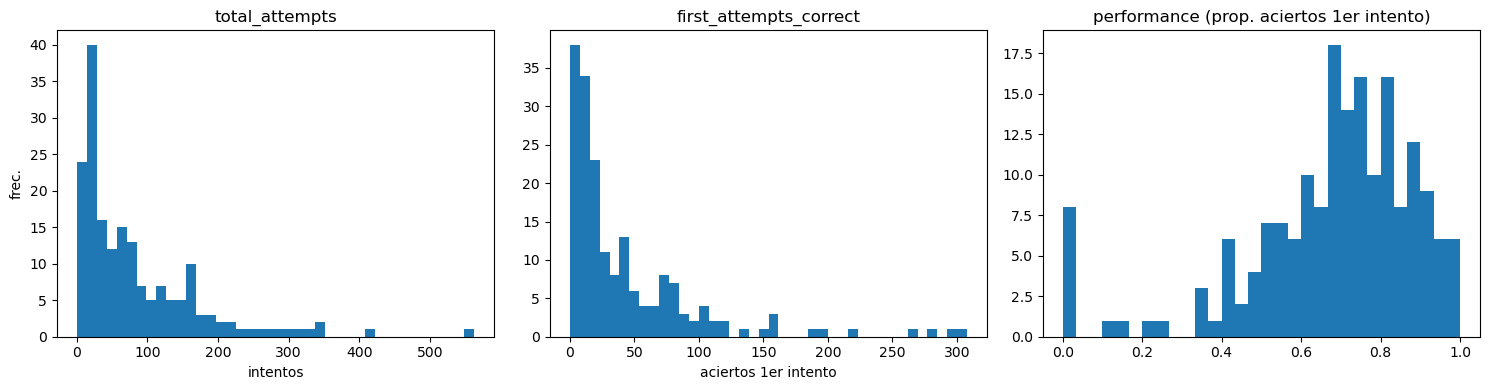

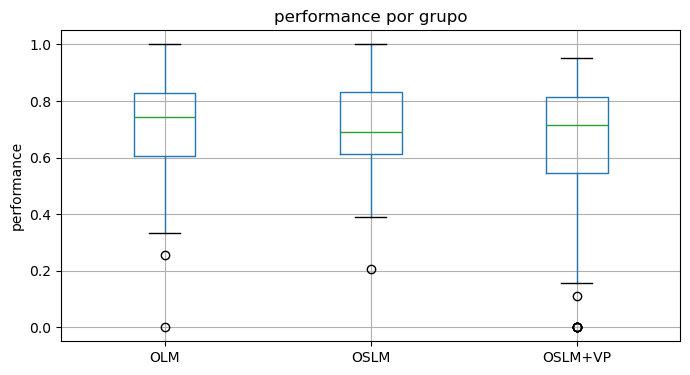


total_attempts por grupo:
                     count    mean     std    min     25%     50%      75%      max
grupo_intervencion                                                                 
OLM                59.0000 84.5760 95.7750 1.0000 22.5000 60.0000 119.5000 563.0000
OSLM               51.0000 87.2160 80.8740 2.0000 24.5000 65.0000 115.5000 344.0000
OSLM+VP            71.0000 78.1550 87.6380 0.0000 19.5000 39.0000 119.0000 419.0000

first_attempts_correct por grupo:
                     count    mean     std    min     25%     50%     75%      max
grupo_intervencion                                                                
OLM                59.0000 44.8470 65.2870 0.0000  8.5000 23.0000 50.0000 308.0000
OSLM               51.0000 44.2750 49.7340 2.0000 11.5000 23.0000 59.0000 219.0000
OSLM+VP            71.0000 41.7460 51.8430 0.0000  6.5000 19.0000 59.0000 268.0000

performance por grupo:
                     count   mean    std    min    25%    50%    75%    max
gru

In [100]:
def graficos_desempeno(df):
    df = df.copy()
    perf = pd.to_numeric(df["performance"], errors="coerce").dropna()
    ta   = pd.to_numeric(df["total_attempts"], errors="coerce").dropna()
    fac  = pd.to_numeric(df["first_attempts_correct"], errors="coerce").dropna()

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].hist(ta, bins=40);   ax[0].set(title="total_attempts", xlabel="intentos", ylabel="frec.")
    ax[1].hist(fac, bins=40);  ax[1].set(title="first_attempts_correct", xlabel="aciertos 1er intento")
    ax[2].hist(perf, bins=30, range=(0, 1)); ax[2].set(title="performance (prop. aciertos 1er intento)")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    df.boxplot(column="performance", by="grupo_intervencion", ax=ax)
    ax.set(title="performance por grupo", xlabel="", ylabel="performance"); plt.suptitle("")
    plt.tight_layout(); plt.show()

graficos_desempeno(dfUsuario)

for c in ["total_attempts", "first_attempts_correct", "performance"]:
    print(f"\n{c} por grupo:")
    print(dfUsuario.groupby("grupo_intervencion")[c].describe().round(3))

## 7. Revisión inversa — matriz de screening variable × factor

**Objetivo.** En vez de preguntar "¿el grupo afecta a la variable X?" una por una, aquí se recorre **cada variable de resultado** y se testea **cada factor** de forma sistemática, para producir una **tabla priorizada** de qué combinaciones muestran cambios y merecen un análisis dedicado.

**Factores evaluados:**
- `grupo` — 3 niveles (OLM / OSLM / OSLM+VP) para variables globales; **OSLM vs OSLM+VP** para variables que solo existen con comparación social.
- `direccion` de comparación (upward / downward / igual).
- `grupo × direccion` (interacción).

**Cómo se testea cada nivel:**
- *Variables de nivel usuario, factor grupo:* Kruskal–Wallis (3 grupos) o Mann–Whitney / Welch t (2 grupos) según supuestos, + epsilon² / eta² / rank-biserial.
- *Pares upward/abajo de nivel usuario (medida intra-sujeto, solo usuarios con casos en ambas direcciones):* Wilcoxon de rangos con signo para la dirección, Mann–Whitney para grupo (OSLM vs OSLM+VP) sobre el promedio por usuario, y Mann–Whitney sobre la diferencia (arriba − abajo) para la interacción.
- *Variables de nivel evento (`dfSegmento`, `dfNivelEjercicio`):* OLS sobre el **rango** de la variable (equivalente no paramétrico factorial) con **errores robustos por conglomerado** (usuario); el p de cada bloque (grupo, dirección, interacción) sale de un **Wald robusto por término**.

Todos los p se ajustan por **FDR (Benjamini–Hochberg)** dentro de cada bloque de screening. La columna `PRIORIDAD` combina significancia ajustada y magnitud del efecto.

### 7.1 Nivel usuario — factor `grupo`

> Se separan **variables globales** (definidas para los 3 grupos → contraste de 3 niveles) de las **variables que solo existen con comparación social** (`*_comparacion*`, `porce_topicos_*`, `preferencia_*`: en OLM son constantes por diseño). Para estas últimas, comparar los 3 grupos solo confirmaría el diseño; el contraste informativo es **OSLM vs OSLM+VP**.

In [101]:
OUTCOMES_GLOBALES = [
    "primer_pollValue", "autoeficacia_general", "casos", "total_attempts", "first_attempts_correct",
    "unique_steps", "performance", "Tasa_exito", "numero_hints", "tasa_hints",
    "numero_sesiones_diferentes", "tiempo_total_segundos", "selectionRating_result", "progreso_inicial",
]
OUTCOMES_SOLO_COMPARACION = [
    "preferencia_casos_comparacion", "preferencia_pasos_comparacion", "proporcion_casos_comparacion",
    "proporcion_steps_comparacion", "porce_topicos_arriba", "porce_topicos_abajo",
    "proporcion_casos_uw", "proporcion_casos_dw",
]

def screen_usuario_grupo(df):
    filas = []
    for v in OUTCOMES_GLOBALES:
        if v not in df.columns:
            continue
        r = contraste_k([df.loc[df.grupo_intervencion == g, v] for g in ORDEN_GRUPOS], variable=v)
        filas.append(dict(nivel="usuario", variable=v, factor="grupo (3)",
                          test=r["test"], stat=r["stat"], p=r["p"],
                          ef=r["ef"], ef_tipo=r["ef_tipo"], n=r["n"]))
    dc = df[df["grupo_intervencion"].isin(GRUPOS_COMP)]
    for v in OUTCOMES_SOLO_COMPARACION:
        if v not in df.columns:
            continue
        r = contraste_2(dc.loc[dc.grupo_intervencion == "OSLM", v],
                        dc.loc[dc.grupo_intervencion == "OSLM+VP", v], variable=v)
        filas.append(dict(nivel="usuario", variable=v, factor="grupo (OSLM vs OSLM+VP)",
                          test=r["test"], stat=r["stat"], p=r["p"],
                          ef=r["ef"], ef_tipo=r["ef_tipo"], n=r["n1"] + r["n2"]))
    t = pd.DataFrame(filas)
    t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_71 = screen_usuario_grupo(dfUsuario)
print(scr_71.sort_values("p_fdr")[["variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]]
      .round(4).to_string(index=False))

                     variable                  factor           test       stat      p  p_fdr      ef       ef_tipo magnitud   n
          proporcion_casos_dw grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,263.5000 0.0144 0.1583 -0.2502 rank-biserial  pequeño 122
          porce_topicos_abajo grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,263.5000 0.0144 0.1583 -0.2502 rank-biserial  pequeño 122
 proporcion_steps_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,051.0000 0.0348 0.1704 -0.2187 rank-biserial  pequeño 117
       selectionRating_result               grupo (3) Kruskal–Wallis     6.5030 0.0387 0.1704  0.0322      epsilon²  pequeño 172
preferencia_pasos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,051.0000 0.0348 0.1704 -0.2187 rank-biserial  pequeño 117
 proporcion_casos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,153.5000 0.0644 0.2025 -0.1895 rank-biserial  pequeño 122
preferencia_casos_comparacion grupo (OSLM vs OSLM+VP) Mann–Whitney U 2,153.5000 0.0644 0.2025 -0.

### 7.2 Nivel usuario — pares upward / downward (dirección, grupo y su interacción)

Cada usuario de OSLM/OSLM+VP aporta un valor `_arriba` y uno `_abajo` (medida intra-sujeto).

> **Corrección de ceros estructurales:** las columnas `*_arriba` / `*_abajo` se rellenaron con 0 cuando el usuario no tuvo casos en esa dirección. Aquí se restringe a usuarios con **≥1 caso en ambas direcciones** (`casos_comparacion_arriba>0` y `casos_comparacion_abajo>0`), para que la comparación arriba vs abajo sea entre valores realmente observados. Esto reduce el N.

In [102]:
PARES_DIR = [
    ("performance",              "performance_arriba",        "performance_abajo"),
    ("pasos_comparacion",        "pasos_comparacion_arriba",  "pasos_comparacion_abajo"),
    ("casos_comparacion",        "casos_comparacion_arriba",  "casos_comparacion_abajo"),
    ("tiempo_casos_comparacion", "tiempo_casos_comparacion_arriba", "tiempo_casos_comparacion_abajo"),
    ("tasa_exito_comparacion",   "tasa_exito_comparacion_arriba",   "tasa_exito_comparacion_abajo"),
    ("autoeficacia_prom_comp",   "autoeficacia_prom_comparacion_arriba", "autoeficacia_prom_comparacion_abajo"),
    ("rating_comparacion",       "rating_comparacion_arriba",  "rating_comparacion_abajo"),
]

def screen_usuario_direccion(df, pares):
    d = df[df["grupo_intervencion"].isin(GRUPOS_COMP)].copy()
    ca = pd.to_numeric(d["casos_comparacion_arriba"], errors="coerce").fillna(0)
    cb = pd.to_numeric(d["casos_comparacion_abajo"], errors="coerce").fillna(0)
    d = d[(ca > 0) & (cb > 0)].copy()
    print(f"Usuarios con casos en ambas direcciones: {len(d)} "
          f"({d['grupo_intervencion'].value_counts().to_dict()})")
    filas = []
    for base, c_up, c_dw in pares:
        if c_up not in d.columns or c_dw not in d.columns:
            continue
        sub = d[["userid", "grupo_intervencion", c_up, c_dw]].copy()
        sub[c_up] = pd.to_numeric(sub[c_up], errors="coerce")
        sub[c_dw] = pd.to_numeric(sub[c_dw], errors="coerce")
        par = sub.dropna(subset=[c_up, c_dw])
        if len(par) < 8:
            continue
        # (i) efecto dirección: Wilcoxon pareado arriba vs abajo
        try:
            w, p_dir = stats.wilcoxon(par[c_up], par[c_dw])
        except ValueError:
            w, p_dir = np.nan, np.nan
        n = len(par)
        # r pareado = Z / sqrt(N)
        if pd.notna(p_dir) and 0 < p_dir < 1:
            z = stats.norm.isf(p_dir / 2)
            r_dir = z / np.sqrt(n)
        else:
            r_dir = np.nan
        filas.append(dict(nivel="usuario", variable=base, factor="direccion (arriba vs abajo, pareado)",
                          test="Wilcoxon", stat=w, p=p_dir, ef=r_dir, ef_tipo="r", n=n))
        # (ii) efecto grupo: MW sobre promedio (arriba, abajo) por usuario
        par = par.assign(_media=(par[c_up] + par[c_dw]) / 2, _dif=par[c_up] - par[c_dw])
        r_g = contraste_2(par.loc[par.grupo_intervencion == "OSLM", "_media"],
                          par.loc[par.grupo_intervencion == "OSLM+VP", "_media"], variable=base)
        filas.append(dict(nivel="usuario", variable=base, factor="grupo (OSLM vs OSLM+VP)",
                          test=r_g["test"], stat=r_g["stat"], p=r_g["p"],
                          ef=r_g["ef"], ef_tipo=r_g["ef_tipo"], n=r_g["n1"] + r_g["n2"]))
        # (iii) interacción: MW sobre la diferencia (arriba - abajo) por usuario
        r_i = contraste_2(par.loc[par.grupo_intervencion == "OSLM", "_dif"],
                          par.loc[par.grupo_intervencion == "OSLM+VP", "_dif"], variable=base)
        filas.append(dict(nivel="usuario", variable=base, factor="grupo × direccion",
                          test=r_i["test"], stat=r_i["stat"], p=r_i["p"],
                          ef=r_i["ef"], ef_tipo=r_i["ef_tipo"], n=r_i["n1"] + r_i["n2"]))
    t = pd.DataFrame(filas)
    t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
    t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_72 = screen_usuario_direccion(dfUsuario, PARES_DIR)
print(scr_72.sort_values("p_fdr")[["variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]]
      .round(4).to_string(index=False))

Usuarios con casos en ambas direcciones: 42 ({'OSLM+VP': 24, 'OSLM': 18, 'OLM': 0})
                variable                               factor           test     stat      p  p_fdr      ef       ef_tipo magnitud  n
  tasa_exito_comparacion direccion (arriba vs abajo, pareado)       Wilcoxon 119.0000 0.0067 0.1407  0.4720             r  mediano 33
             performance                    grupo × direccion Mann–Whitney U 121.0000 0.0163 0.1711  0.4398 rank-biserial  mediano 42
             performance direccion (arriba vs abajo, pareado)       Wilcoxon 366.0000 0.7377 0.8698  0.0517             r  trivial 42
      rating_comparacion direccion (arriba vs abajo, pareado)       Wilcoxon  63.0000 0.5227 0.8698  0.1167             r  pequeño 30
  autoeficacia_prom_comp                    grupo × direccion Mann–Whitney U  93.0000 0.5391 0.8698  0.1389 rank-biserial  pequeño 30
  autoeficacia_prom_comp              grupo (OSLM vs OSLM+VP)        Welch t  -0.3386 0.7383 0.8698 -0.1285     

### 7.3 Nivel evento — `grupo`, `direccion` y `grupo × direccion` (OLS robusto sobre rangos)

Para cada variable se ajusta `rango(variable) ~ C(grupo) * C(direccion)` por OLS con errores robustos por conglomerado (usuario). El p de cada bloque es el **Wald robusto del término** (`wald_test_terms`); `ef ≈ R²(≈)` = `stat/(stat+N)`, solo para ordenar. En `dfSegmento` la dirección (`arriba` / `abajo` / `igual`) se evalúa dentro de OSLM ∪ OSLM+VP (en OLM siempre es `no`). En `dfNivelEjercicio` la dirección es la posición objetiva (existe para los 3 grupos) pero viene **propagada por usuario con ffill/bfill** (proxy ruidoso) y la categoría `igual` está vacía en OLM → se usa solo `arriba` / `abajo`.

In [103]:
def _fila_evento(nivel, v, factor, res, termino, n):
    w = res.wald_test_terms(scalar=True).summary_frame()
    w.columns = [str(c) for c in w.columns]
    statcol = next(c for c in w.columns if c.lower() in ("f", "chi2", "statistic"))
    pcol = next(c for c in w.columns if c.lower().startswith("p"))
    stat = float(w.loc[termino, statcol]); p = float(w.loc[termino, pcol])
    ef = stat / (stat + n) if (stat + n) else np.nan          # R²(≈) parcial, solo para ordenar
    return dict(nivel=nivel, variable=v, factor=factor, test="Wald robusto (rango)",
                stat=stat, p=p, ef=ef, ef_tipo="R²(≈)", n=n)

def screen_evento(df, outcomes, etiqueta, direccion_confundida_con_OLM, dir_niveles=("arriba", "abajo", "igual")):
    filas = []
    d = df.copy()
    d["grupo_intervencion"] = d["grupo_intervencion"].astype(str)
    d["direccion"] = d["direccion"].where(d["direccion"].isin(dir_niveles))
    for v in outcomes:
        if v not in d.columns:
            continue
        sv = d[["userid", "grupo_intervencion", "direccion", v]].copy()
        sv[v] = pd.to_numeric(sv[v], errors="coerce")

        # --- efecto grupo (3 niveles, sin filtrar por dirección) ---
        sg = sv.dropna(subset=["grupo_intervencion", v]).copy()
        if sg["userid"].nunique() >= 10 and len(sg) >= 40 and sg["grupo_intervencion"].nunique() >= 2:
            sg["rango"] = sg[v].rank()
            try:
                r = smf.ols("rango ~ C(grupo_intervencion)", sg).fit(
                    cov_type="cluster", cov_kwds={"groups": sg["userid"].astype(str)})
                filas.append(_fila_evento(etiqueta, v, "grupo (3)", r, "C(grupo_intervencion)", len(sg)))
            except Exception as e:
                print(f"  [aviso] {etiqueta}/{v}/grupo: {type(e).__name__}: {e}")

        # --- dirección e interacción ---
        sd = sv.dropna(subset=["direccion", v]).copy()
        if direccion_confundida_con_OLM:
            sd = sd[sd["grupo_intervencion"].isin(GRUPOS_COMP)]
        celdas = pd.crosstab(sd["grupo_intervencion"], sd["direccion"])
        rango_completo = (celdas.values >= 5).all() and celdas.shape[1] >= 2
        if sd["userid"].nunique() >= 10 and len(sd) >= 40 and rango_completo:
            sd["rango"] = sd[v].rank()
            multi_g = sd["grupo_intervencion"].nunique() >= 2
            f = ("rango ~ C(grupo_intervencion) * C(direccion)" if multi_g
                 else "rango ~ C(direccion)")
            try:
                r = smf.ols(f, sd).fit(cov_type="cluster",
                                       cov_kwds={"groups": sd["userid"].astype(str)})
                filas.append(_fila_evento(etiqueta, v, "direccion", r, "C(direccion)", len(sd)))
                if multi_g:
                    filas.append(_fila_evento(etiqueta, v, "grupo × direccion", r,
                                              "C(grupo_intervencion):C(direccion)", len(sd)))
            except Exception as e:
                print(f"  [aviso] {etiqueta}/{v}/direccion: {type(e).__name__}: {e}")
    t = pd.DataFrame(filas)
    if not t.empty:
        t["p_fdr"] = ajustar_p(t["p"], "fdr_bh")
        t["magnitud"] = [magnitud(e, tp) for e, tp in zip(t["ef"], t["ef_tipo"])]
    return t

scr_seq = screen_evento(dfSegmento,
                        ["pollValue", "pollValue_next", "delta_pollValue", "total_attempts",
                         "first_attempts_correct", "prop_first_attempts_correct", "unique_steps",
                         "selectionRating_result"],
                        "evento:dfSegmento", direccion_confundida_con_OLM=True)
scr_niv = screen_evento(dfNivelEjercicio,
                        ["first_attempts_correct", "prop_first_attempts_correct", "total_attempts",
                         "total_hints", "unique_steps", "duracion_segundos", "selectionRating_result",
                         "pollValue_num"],
                        "evento:dfNivelEjercicio", direccion_confundida_con_OLM=False,
                        dir_niveles=("arriba", "abajo"))  # 'igual' casi ausente y vacío en OLM -> matriz singular

for nombre, t in [("dfSegmento", scr_seq), ("dfNivelEjercicio", scr_niv)]:
    print(f"\n=== {nombre} ===")
    if t.empty:
        print("  (sin resultados)")
    else:
        print(t.sort_values("p_fdr")[["variable", "factor", "stat", "p", "p_fdr", "ef", "magnitud", "n"]]
              .round(4).to_string(index=False))


=== dfSegmento ===
                   variable            factor   stat      p  p_fdr     ef magnitud   n
            delta_pollValue grupo × direccion 7.6026 0.0223 0.1341 0.0255  pequeño 290
     first_attempts_correct         direccion 8.0794 0.0176 0.1341 0.0142  pequeño 561
               unique_steps         direccion 8.9164 0.0116 0.1341 0.0156  pequeño 561
            delta_pollValue         grupo (3) 8.1121 0.0173 0.1341 0.0162  pequeño 493
            delta_pollValue         direccion 6.2879 0.0431 0.2069 0.0212  pequeño 290
     selectionRating_result grupo × direccion 4.9464 0.0843 0.2891 0.0092  trivial 530
             pollValue_next         direccion 5.1930 0.0745 0.2891 0.0176  pequeño 290
     selectionRating_result         direccion 4.3372 0.1143 0.3430 0.0081  trivial 530
             pollValue_next grupo × direccion 3.8776 0.1439 0.3837 0.0132  pequeño 290
                  pollValue grupo × direccion 2.6168 0.2702 0.5405 0.0046  trivial 561
             total_atte

### 7.4 Tabla consolidada y priorización

In [104]:
COLS = ["nivel", "variable", "factor", "test", "stat", "p", "p_fdr", "ef", "ef_tipo", "magnitud", "n"]
consolidado = pd.concat([d for d in [scr_71, scr_72, scr_seq, scr_niv] if not d.empty],
                        ignore_index=True)[COLS]

def prioridad(row):
    if pd.isna(row["p_fdr"]):
        return "—"
    if row["p_fdr"] < .05:
        if row["magnitud"] in ("mediano", "grande"):
            return "ALTA"
        if row["magnitud"] == "pequeño":
            return "media"
        return "detectable, efecto trivial"
    if row["p"] < .05:
        return "revisar (no sobrevive FDR)"
    return "baja"

_ORD = {"ALTA": 0, "media": 1, "revisar (no sobrevive FDR)": 2,
        "detectable, efecto trivial": 3, "baja": 4, "—": 5}
consolidado["PRIORIDAD"] = consolidado.apply(prioridad, axis=1)
consolidado = consolidado.sort_values(
    ["PRIORIDAD", "p_fdr"],
    key=lambda c: c.map(_ORD) if c.name == "PRIORIDAD" else c)
print("=== MATRIZ DE SCREENING (ordenada por prioridad) ===\n")
print(consolidado.round(4).to_string(index=False))

print("\n--- Combinaciones de PRIORIDAD ALTA (merecen análisis dedicado) ---")
alta = consolidado[consolidado["PRIORIDAD"] == "ALTA"]
if alta.empty:
    print("  Ninguna combinación variable × factor alcanza prioridad ALTA.")
else:
    for _, r in alta.iterrows():
        print(f"  • [{r['nivel']}] {r['variable']}  —  {r['factor']}: "
              f"{r['test']}, p_fdr={r['p_fdr']:.4f}, {r['ef_tipo']}={r['ef']:.3f} ({r['magnitud']})")

=== MATRIZ DE SCREENING (ordenada por prioridad) ===

                  nivel                      variable                               factor                 test       stat      p  p_fdr      ef       ef_tipo magnitud    n                  PRIORIDAD
evento:dfNivelEjercicio             duracion_segundos                    grupo × direccion Wald robusto (rango)     8.2806 0.0159 0.1167  0.0017         R²(≈)  trivial 4873 revisar (no sobrevive FDR)
evento:dfNivelEjercicio        selectionRating_result                            direccion Wald robusto (rango)     6.1200 0.0134 0.1167  0.0014         R²(≈)  trivial 4398 revisar (no sobrevive FDR)
      evento:dfSegmento               delta_pollValue                            grupo (3) Wald robusto (rango)     8.1121 0.0173 0.1341  0.0162         R²(≈)  pequeño  493 revisar (no sobrevive FDR)
      evento:dfSegmento               delta_pollValue                    grupo × direccion Wald robusto (rango)     7.6026 0.0223 0.1341  0.0255  

### 7.5 Mapa de calor variable × factor

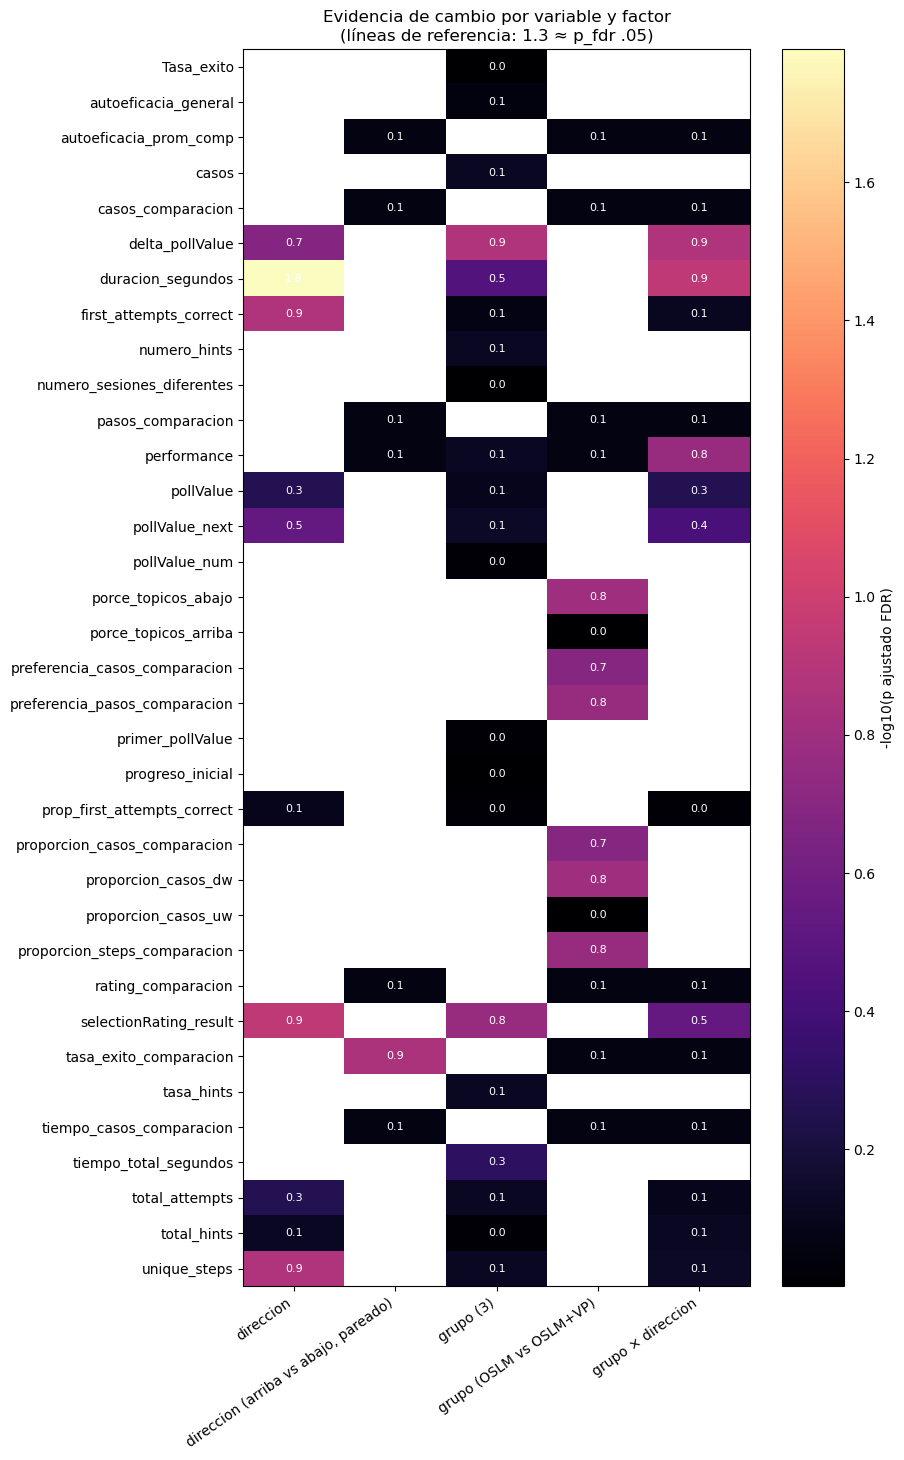

In [105]:
piv = (consolidado.assign(signif=lambda d: -np.log10(d["p_fdr"].clip(lower=1e-6)))
       .pivot_table(index="variable", columns="factor", values="signif", aggfunc="max"))

fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(piv))))
im = ax.imshow(piv.values, aspect="auto", cmap="magma")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=35, ha="right")
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        val = piv.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    color="white" if val < 2 else "black", fontsize=8)
cb = plt.colorbar(im, ax=ax); cb.set_label("-log10(p ajustado FDR)")
ax.set_title("Evidencia de cambio por variable y factor\n(líneas de referencia: 1.3 ≈ p_fdr .05)")
plt.tight_layout(); plt.show()

### 7.6 Lectura de la revisión inversa

- **ALTA** → sobrevive la corrección FDR y con magnitud ≥ mediana. Modelar en detalle (modelo dedicado, post-hoc, control de covariables, supuestos y casos influyentes).
- **media** → significativo tras FDR con efecto pequeño: reportar con cautela sobre su relevancia práctica.
- **detectable, efecto trivial** → p ajustado < .05 pero magnitud despreciable (típico de N grande, p. ej. la dirección *ffilleada* en `dfNivelEjercicio`): probablemente no interpretable.
- **revisar (no sobrevive FDR)** → p < .05 sin corregir; posible ruido por comparaciones múltiples. Seguir solo si hay hipótesis previa **o** un test focalizado bien especificado lo confirma.

El screening usa tests de rango y aproximaciones (Wald robusto, R²≈) pensados para **triaje**, no como resultado final. Cada combinación priorizada debe re-analizarse con el modelo adecuado.

**Síntesis de esta corrida:** ninguna combinación llega a ALTA. Las señales que aparecen de forma repetida (sin corregir) y que se re-analizan en §3.4 y §4: (1) **cambio de autoeficacia según grupo** — en el screening figura como *revisar*; al re-analizarlo bien (§3.4, una observación por usuario) el efecto es **borderline** (KW por usuario p ≈ .19; ANCOVA ajustando por basal: OSLM vs OLM p ≈ .05); (2) **selección de contenido con comparación social entre OSLM y OSLM+VP** (`preferencia_pasos_comparacion`, `proporcion_casos_dw` / `porce_topicos_abajo`) — p sin corregir ≈ .01–.05, efecto pequeño, **no sobrevive** la corrección; (3) **desempeño por dirección × grupo** — efecto mediano pero N = 42 y el efecto principal de dirección es nulo: solo hipótesis.

## 8. Síntesis de hallazgos y de correcciones aplicadas

### Hallazgos
- **Equilibrio basal.** Los tres grupos son equivalentes en autoeficacia inicial (`primer_pollValue`, KW p ≈ .73) → la aleatorización funcionó.
- **Autoeficacia sube con el tiempo (robusto).** En el modelo de crecimiento `pollValue ~ tiempo × grupo` (RE por usuario, ICC ≈ .60) el efecto de tiempo es grande y muy significativo: **+9.6 puntos por medición** (χ²(1) ≈ 8.0, p ≈ .005). Vale para los tres grupos.
- **Diferencias de grupo en el cambio: no robustas.** (a) KW sobre Δautoeficacia **por usuario** (1 dato/persona): p ≈ .19, ns. (b) ANCOVA ajustando por autoeficacia basal: OSLM vs OLM = −5.5 pts, **p ≈ .05** (borderline); OSLM+VP ≈ OLM. (c) Interacción tiempo × grupo: omnibus **p ≈ .05**, empujada por OSLM+VP con pendiente algo más pronunciada que OLM (p ≈ .02). La dirección del efecto **cambia según la especificación** y ningún contraste sobrevive corrección → no es un hallazgo confirmatorio. El KW p ≈ .001 del notebook original era **pseudorreplicación** (490 transiciones no independientes).
- **Contrastes de grupo en el modelo autorregresivo** (`pollValue_next ~ …`): no significativos en el conjunto ni por transición (OSLM+VP vs OSLM borderline en D2→D3, p ≈ .07). Predictor dominante: la autoeficacia previa.
- **Selección de subtópicos (Pregunta 3.1).** Entre OSLM y OSLM+VP: `preferencia_pasos_comparacion` (medianas −0.06 vs −0.87) y `porce_topicos_abajo` / `proporcion_casos_dw` (0.33 vs 0.00) difieren con p sin corregir ≈ .01–.05 y efecto pequeño (rank-biserial ≈ −.22 a −.25); **no sobreviven** Holm. El 46 % de los usuarios de OSLM+VP nunca elige casos con comparación, vs 29 % en OSLM. `progreso_inicial` no difiere entre grupos. **Advertencia:** estas variables dependen en parte del nº de casos hechos (OSLM+VP hizo menos), así que no son elección 'pura'.
- **Desempeño (Pregunta 3.2).** `performance` global no difiere entre grupos (KW p ≈ .44). El aparente efecto de `performance_abajo` (OSLM > OSLM+VP) **desaparece** al restringir a usuarios con casos reales en esa dirección (era artefacto de los ceros estructurales; n baja de 122 a 42).
- **Revisión inversa (§7).** Ninguna combinación variable × factor alcanza prioridad ALTA tras FDR.
- **Limitaciones de potencia.** Solo ~105/181 usuarios tienen autoeficacia medida y solo ~80 aparecen con Δ (29/27/24 por grupo); los análisis por dirección se apoyan en 42 usuarios. Los resultados nulos deben leerse como *no detectamos efecto*, no como *no hay efecto*.

## 9. Qué podemos sostner

Redacción breve, calibrada a lo que los datos aguantan. Diseño: 181 estudiantes asignados a **OLM** (modelo abierto individual), **OSLM** (+ comparación social) u **OSLM+VP** (+ mensajes motivacionales). Autoeficacia medida repetidamente (escala 0–100) dentro de cada tópico.

1. **La autoeficacia percibida aumenta de forma sustancial a lo largo del uso de la plataforma, en las tres condiciones.** En un modelo de crecimiento con intercepto aleatorio por estudiante, cada medición sucesiva se asocia a ≈ +9–10 puntos (p < .01); el patrón se sostiene al modelar la no-independencia de las medidas. No es atribuible a una condición concreta: **abrir el modelo del estudiante —con o sin comparación social— acompaña una trayectoria ascendente de autoeficacia.**
2. **La aleatorización produjo grupos equivalentes en autoeficacia inicial** (p ≈ .73), lo que da validez interna a las comparaciones.
3. **No se detectan efectos de la comparación social (OSLM vs OLM) ni del mensaje motivacional (OSLM+VP vs OSLM) sobre el desempeño** (proporción de pasos correctos al primer intento, tasa de éxito, uso de pistas, tiempo): todas las diferencias son de tamaño de efecto trivial y no significativas. Con el N disponible, **la comparación social no perjudicó ni mejoró el rendimiento.**
4. **Señal exploratoria, no confirmatoria, sobre la autoeficacia:** al ajustar por el nivel basal, el grupo que vio comparación social **sin** mensaje motivacional (OSLM) muestra un incremento de autoeficacia ≈ 5 puntos menor que el control (p ≈ .05), mientras que añadir el mensaje motivacional (OSLM+VP) lo deja al nivel del control. Es **coherente con la teoría de comparación social** (la comparación puede atenuar la autoeficacia y un andamiaje motivacional la protege), pero el efecto es pequeño, depende de la especificación del modelo y no sobrevive corrección por comparaciones múltiples. **Se reporta como hipótesis a confirmar, no como resultado.**
5. **Diferencia exploratoria en el uso de contenido con comparación:** los estudiantes de OSLM+VP tendieron a seleccionar menos casos con comparación social que los de OSLM (46 % vs 29 % no eligió ninguno; efecto pequeño, p sin corregir ≈ .03–.05). Puede sugerir que el mensaje motivacional reorienta la atención fuera de la comparación, pero está parcialmente confundido con el volumen de actividad y no sobrevive corrección.